# Multimodal: RNA + protein (CITE-seq)

RNA/ADT interoperability in PBMC CITE-seq data

CITE-seq measures transcripts and surface proteins in the same cells.
This workflow uses a PBMC dataset to combine RNA and antibody-derived
tag (ADT) measurements with BiocPy, AnnData, MuData, and ggnomics.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("_includes").resolve()))
from setup import configure_warnings, ensure_matplotlib_initialized
ensure_matplotlib_initialized()
configure_warnings()

import numpy as np
import pandas as pd
import ggnomics as gg
from plotnine import theme_bw, labs, theme

## 1. Data source

ExperimentHub resource `EH7740` (`CITEVizTestDataSCE`, approximately
2,500 cells) is distributed as a multimodal `SingleCellExperiment`. With
the current `experimenthub`/`rds2py` versions, its nested `int_colData`
structure cannot be parsed:

In [2]:
from experimenthub import ExperimentHubRegistry
from setup import EXPERIMENTHUB_CACHE

hub = ExperimentHubRegistry(cache_dir=str(EXPERIMENTHUB_CACHE))
try:
    hub.load("EH7740")
except Exception as exc:
    print(f"{type(exc).__name__}: {str(exc)[:200]}...")

Package 'multiassayexperiment' is not installed.
RuntimeError: Failed to load R data from /home/maximiliann/.cache/ggnomics-docs/experimenthub/39284e0ebbff45269ed5ad6956a86002_pbmc-cite-seq-2500-sce.rds: Error initializing 'PyRdsParser': Error in 'RdsObject' cons...

We therefore use the Mair et al. BD Rhapsody PBMC resources
`EH3534`–`EH3538`, which provide 499 RNA features, 42 ADT features, and
29,033 droplets from three main donors. The individual ExperimentHub
resources are assembled by `load_pbmc_cite_seq()`.

In [3]:
from data import load_pbmc_cite_seq

mods, note = load_pbmc_cite_seq()
note

"EH7740 failed to load (RuntimeError: Failed to load R data from /home/maximiliann/.cache/ggnomics-docs/experimenthub/39284e0ebbff45269ed5ad6956a86002_pbmc-cite-seq-2500-sce.rds: Error initializing 'PyRdsParser': Error in 'RdsObject' constructor: failed to parse an S4 object's body\n  - failed to parse a pairlist body\n  - failed to parse pairlist element 'int_colData'\n  - failed to parse an S4 object's body\n  - failed to parse a pairlist body\n  - failed to parse pairlist element 'listData'\n  - failed to parse an R list body\n  - failed to parse list element 2\n  - failed to parse an S4 object's body\n  - failed to parse a pairlist body\n  - failed to parse pairlist element 'listData'\n  - failed to parse an R list body\n  - failed to parse list element 1\n  - failed to parse an S4 object's body\n  - class attribute in an S4 object should have a 'package' character attribute); using EH3534-EH3538 fallback"

## 2. Discovering the RNA and ADT representations

In [4]:
rna, adt = mods["rna"], mods["adt"]
rna

AnnData object with n_obs × n_vars = 27258 × 499
    obs: 'sample_tag', 'donor', 'cartridge'
    var: 'RefSeq', 'Type'
    layers: None (.X)

In [5]:
adt

AnnData object with n_obs × n_vars = 27258 × 42
    obs: 'sample_tag', 'donor', 'cartridge'
    var: 'Alternative', 'ID'
    layers: None (.X)

In [6]:
adt.obs["donor"].value_counts()

donor
Donor2_Bulk    9150
Donor1_Bulk    8932
Donor3_Bulk    8843
Donor2_EBV      168
Donor3_EBV      113
Donor1_EBV       52
Name: count, dtype: int64

## 3. Validating shared cell identifiers

The two cartridges reuse some numeric barcodes, so a barcode alone is
not a unique cell identifier. The loader combines barcode and cartridge,
verifies the correspondence between modalities, and preserves the
resulting order. After assembly, the RNA and ADT observation names
should match:

In [7]:
(rna.obs_names == adt.obs_names).all()

np.True_

## 4. Mapping RNA genes to ADT proteins

Protein names do not always match their corresponding gene symbols.
`adt.var["Alternative"]` provides the mapping used here:

In [8]:
rna_genes = set(rna.var_names)
matched = [(protein, gene) for protein, gene in adt.var["Alternative"].items() if gene in rna_genes]
len(matched), matched[:8]

(38,
 [('CD103', 'ITGAE'),
  ('CD11b', 'ITGAM'),
  ('CD11c', 'ITGAX'),
  ('CD123', 'IL3RA'),
  ('CD127', 'IL7R'),
  ('CD134', 'TNFRSF4'),
  ('CD137', 'TNFRSF9'),
  ('CD141', 'THBD')])

## 5. RNA QC and ADT QC

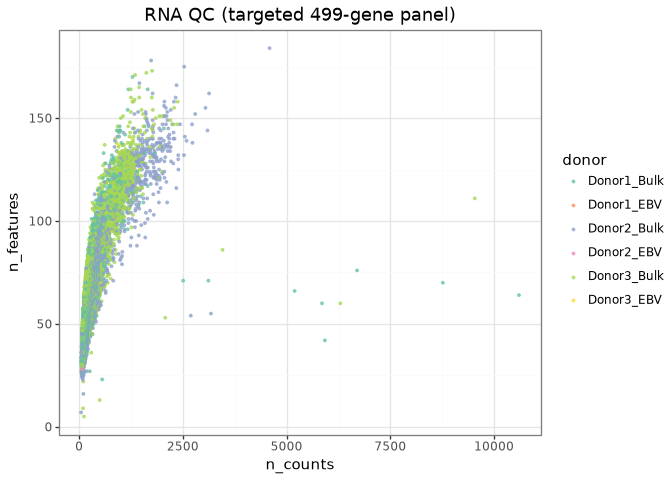

In [9]:
rna_qc = pd.DataFrame({
    "n_counts": np.asarray(rna.X.sum(axis=1)).ravel(),
    "n_features": (rna.X > 0).sum(axis=1),
    "donor": rna.obs["donor"].to_numpy(),
})
gg.plot_coldata(rna_qc, x="n_counts", y="n_features", color_by="donor") + theme_bw() + labs(title="RNA QC (targeted 499-gene panel)")

`plot_adt_qc` uses isotype controls to estimate background signal. This
panel contains immune markers but no annotated isotype-control
antibodies, as seen from its feature names:

In [10]:
sorted(adt.var_names)

['CD103',
 'CD11b',
 'CD11c',
 'CD123',
 'CD127',
 'CD134',
 'CD137',
 'CD14',
 'CD141',
 'CD16',
 'CD161',
 'CD163',
 'CD183',
 'CD184',
 'CD19',
 'CD194',
 'CD196',
 'CD197',
 'CD1c',
 'CD206',
 'CD223',
 'CD25',
 'CD27',
 'CD278',
 'CD279',
 'CD28',
 'CD3',
 'CD32',
 'CD38',
 'CD39',
 'CD4',
 'CD40',
 'CD45RA',
 'CD45RO',
 'CD56',
 'CD69',
 'CD8',
 'CD80',
 'CD86',
 'HLA-DR',
 'TCRgd',
 'Tim3']

In [11]:
try:
    gg.plot_adt_qc(adt, isotype_controls=[])
except ValueError as exc:
    print("ValueError:", exc)

ValueError: isotype_controls must be a non-empty list.

The function therefore cannot calculate an isotype-based QC summary for
this dataset. The empty control list in the check above shows the
corresponding validation error; the [API reference](../api/modules.rst)
documents the required input.

A control-free library-size check can still be drawn with
`plot_coldata`:

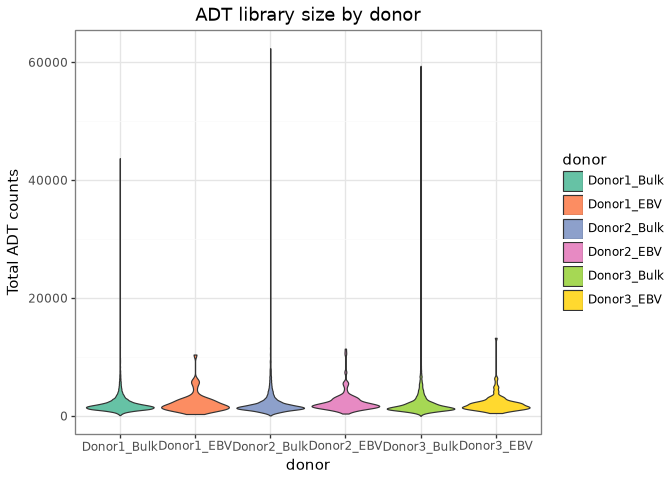

In [12]:
adt_qc = pd.DataFrame({
    "adt_counts": np.asarray(adt.X.sum(axis=1)).ravel(),
    "donor": adt.obs["donor"].to_numpy(),
})
gg.plot_coldata(adt_qc, x="donor", y="adt_counts", shape="violin") + theme_bw() + labs(title="ADT library size by donor", y="Total ADT counts")

The raw ADT counts are strongly right-skewed, so the scatter and
embedding plots below use a log1p-transformed copy of the ADT modality:

In [13]:
adt_log = adt.copy()
adt_log.X = np.log1p(adt_log.X)

## 6. RNA-versus-protein scatter (MuData)

In [14]:
import mudata as mu

mu.set_options(pull_on_update=False)
mdata = mu.MuData({"rna": rna, "prot": adt_log})
mdata

MuData object with n_obs × n_vars = 27258 × 541
 2 modalities
 rna: 27258 × 499
 obs: 'sample_tag', 'donor', 'cartridge'
 var: 'RefSeq', 'Type'
 layers: None
 prot: 27258 × 42
 obs: 'sample_tag', 'donor', 'cartridge'
 var: 'Alternative', 'ID'
 layers: None

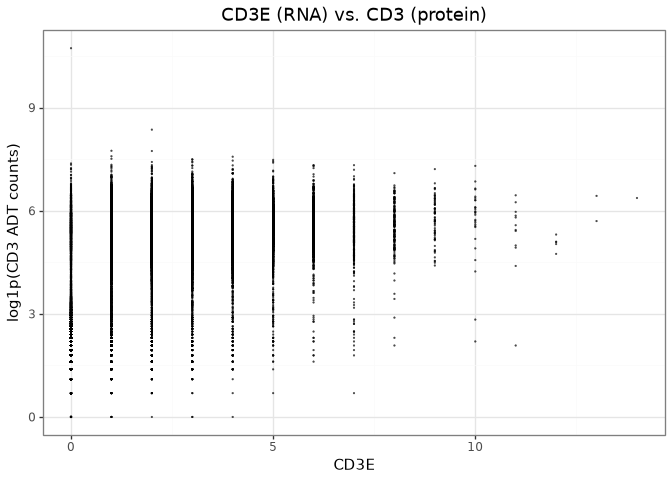

In [15]:
gg.plot_bimodal_scatter(mdata, x_feature="CD3E", y_feature="CD3", x_mod="rna", y_mod="prot") + theme_bw() + labs(title="CD3E (RNA) vs. CD3 (protein)", y="log1p(CD3 ADT counts)")

## 7. Matched gene/protein panel

In [16]:
pairs = [(gene, protein) for protein, gene in matched if protein in ("CD3", "CD4", "CD8", "CD38")]
pairs

[('CD38', 'CD38'), ('CD3E', 'CD3'), ('CD4', 'CD4'), ('CD8A', 'CD8')]

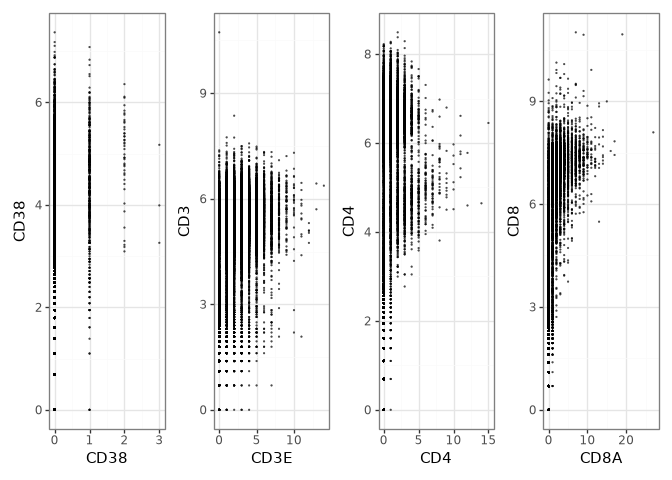

In [17]:
panels = [
    gg.plot_bimodal_scatter(mdata, x_feature=g, y_feature=p, x_mod="rna", y_mod="prot") + theme_bw() + theme(figure_size=(3, 3))
    for g, p in pairs
]
panels[0] | panels[1] | panels[2] | panels[3]

## 8. An embedding computed from RNA, colored by RNA and by protein

The ExperimentHub bundle does not include an embedding. We calculate QC
metrics, normalize the RNA counts, and run PCA and UMAP with `scranpy`,
following the [single-cell workflow](single-cell-scranpy.ipynb). HVG
selection is omitted because this is already a targeted 499-gene panel.
The processed object is cached by
`run_scranpy_pipeline_on_cite_seq_rna()`.

In [18]:
from data import run_scranpy_pipeline_on_cite_seq_rna

final_rna = run_scranpy_pipeline_on_cite_seq_rna()
final_rna.get_reduced_dim_names()

['PCA', 'TSNE', 'UMAP']

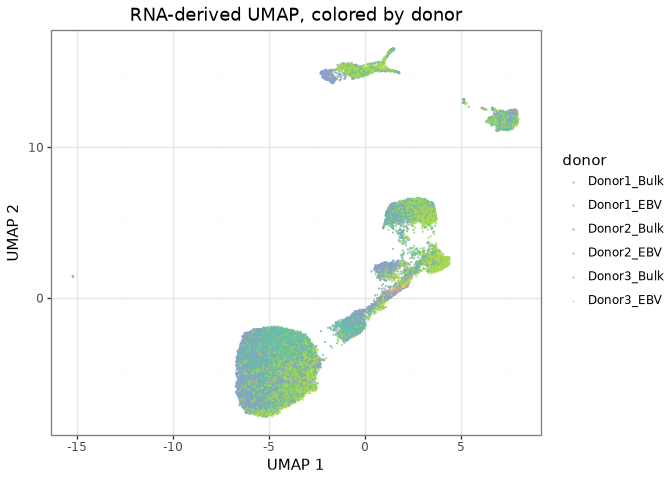

In [19]:
final_for_export = final_rna.set_metadata({})
adata_final, _alt = final_for_export.to_anndata()
adata_final.X = adata_final.layers["counts"]

# Align the ADT modality to exactly the QC-passing RNA cells (order preserved).
adt_aligned = adt_log[adata_final.obs_names, :]
for protein in ("CD3", "CD4", "CD8", "CD38"):
    adata_final.obs[f"ADT_{protein}"] = np.asarray(adt_aligned[:, protein].X).ravel()

gg.plot_umap(adata_final, color="donor") + theme_bw() + labs(title="RNA-derived UMAP, colored by donor")

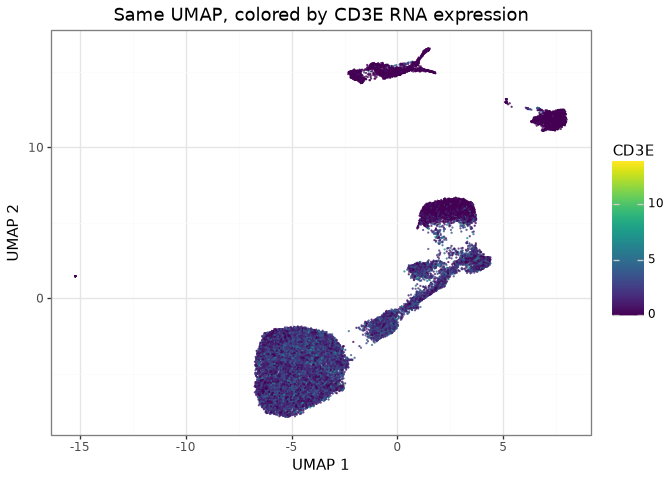

In [20]:
gg.plot_umap(adata_final, color="CD3E", layer="counts") + theme_bw() + labs(title="Same UMAP, colored by CD3E RNA expression")

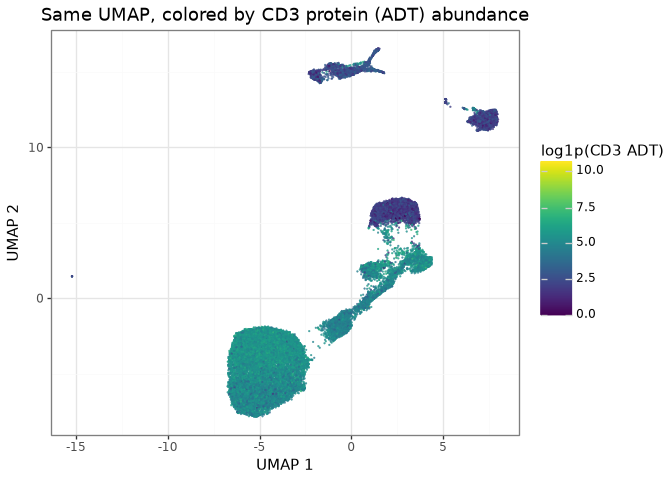

In [21]:
gg.plot_umap(adata_final, color="ADT_CD3") + theme_bw() + labs(title="Same UMAP, colored by CD3 protein (ADT) abundance", colour="log1p(CD3 ADT)")

RNA and protein measurements both highlight the CD3-high T-cell region,
providing a simple visual comparison across modalities.

## 9. Composability

Because both embeddings are returned as `ggplot` objects, they can be
placed side by side with plotnine’s composition operator:

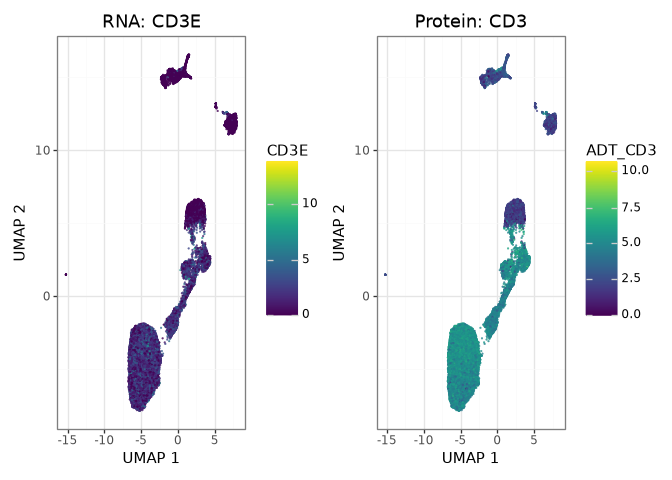

In [22]:
umap_rna = gg.plot_umap(adata_final, color="CD3E", layer="counts") + theme_bw() + labs(title="RNA: CD3E")
umap_adt = gg.plot_umap(adata_final, color="ADT_CD3") + theme_bw() + labs(title="Protein: CD3")
umap_rna | umap_adt

## Next

- [Specialized plots](specialized-plots.ipynb) and the [plot
  gallery](plot-gallery.ipynb) for everything else, including the
  repertoire and significance-bracket functionality.